# SVM emotion classification using HOG feature extraction

In [2]:
# library used to save trained models into the .onnx format
!pip install -q skl2onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 106.8 MB/s eta 0:00:00


In [3]:
# download dataset FER-2013 from kaggle
import os
!mkdir -p ~/.kaggle
!kaggle datasets download -d msambare/fer2013 -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 75.3MB/s]



In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnx

In [31]:
emotion_map = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 4,
    'sad': 5,
    'surprise': 6
}

# parameters for hog feature extraction
hog_params = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
)

def hog_features(image):
    return hog(image, **hog_params).astype(np.float32)

# function that loads images into X data and y labels after hog
def load_images(root):

    X, y = [], []
    for emotion_name, emotion_id in emotion_map.items():

        folder_path = os.path.join(root, emotion_name)
        filenames = os.listdir(folder_path)

        for filename in filenames:
            img_path = os.path.join(folder_path, filename)
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            features = hog_features(image)
            X.append(features)
            y.append(emotion_id)

    return np.array(X), np.array(y)

In [32]:
train_dir = './data/train'
test_dir = './data/test'

# gets training and test datasets
X_train, y_train = load_images(train_dir)
X_test, y_test = load_images(test_dir)

print(f"\nTraining set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} samples, {X_test.shape[1]} features")


Training set: 28709 samples, 900 features
Testing set:  7178 samples, 900 features


In [33]:
# pipeline that normalizes input before svm
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C=0.1, dual=False, max_iter=5000)),
])

# fit and predict
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Accuracy: 43.42%

Classification Report:
              precision    recall  f1-score   support

       angry      0.347     0.259     0.296       958
     disgust      0.386     0.288     0.330       111
        fear      0.330     0.188     0.240      1024
       happy      0.521     0.769     0.621      1774
     neutral      0.381     0.413     0.396      1233
         sad      0.329     0.243     0.280      1247
    surprise      0.507     0.563     0.534       831

    accuracy                          0.434      7178
   macro avg      0.400     0.389     0.385      7178
weighted avg      0.410     0.434     0.411      7178



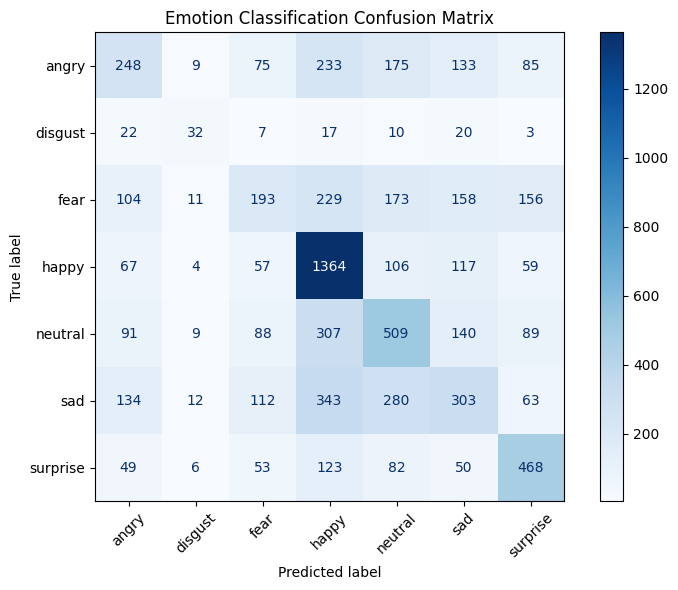

In [34]:

# calculate accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%\n")

# target class labels in order
target_names = list(emotion_map.keys())

# classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

# plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=target_names,
    cmap='Blues',
    ax=ax,
    xticks_rotation=45
)
plt.title('Emotion Classification Confusion Matrix')
plt.tight_layout()
plt.show()

In [35]:
# converts the pipeline into a .onnx file
import numpy as np, onnx
from onnx import helper, TensorProto, numpy_helper

scaler = model.named_steps["scaler"]
svm = model.named_steps["svm"]

W = (svm.coef_ / scaler.scale_).T.astype(np.float32)
b = (svm.intercept_ - (svm.coef_ * scaler.mean_ / scaler.scale_).sum(axis=1)).astype(np.float32)

n_features, n_classes = W.shape
inp = helper.make_tensor_value_info("input", TensorProto.FLOAT, [None, n_features])
out_label = helper.make_tensor_value_info("label", TensorProto.INT64, [None])
out_scores = helper.make_tensor_value_info("scores", TensorProto.FLOAT, [None, n_classes])

nodes = [
    helper.make_node("Gemm", ["input", "W", "b"], ["scores"]),
    helper.make_node("ArgMax", ["scores"], ["label"], axis=1, keepdims=0),
]
graph = helper.make_graph(
    nodes, "hog_linear_svm", [inp], [out_label, out_scores],
    initializer=[numpy_helper.from_array(W, "W"), numpy_helper.from_array(b, "b")],
)
onnx_model = helper.make_model(graph, opset_imports=[helper.make_opsetid("", 13)])
onnx_model.ir_version = 8
onnx.checker.check_model(onnx_model)

output_path = "hog_svm.onnx"
onnx.save_model(onnx_model, output_path)
print(f"Successfully converted and saved to {output_path}")

Successfully converted and saved to hog_svm.onnx
